In [ ]:
#!git clone https://github.com/ImagingYeditepe/Segmentation-of-Teeth-in-Panoramic-X-ray-Image.git
#import sys
#sys.path.append("/content/Segmentation-of-Teeth-in-Panoramic-X-ray-Image")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import sys
from PIL import Image
from zipfile import ZipFile
from natsort import natsorted
from google.colab import drive
import requests
from io import BytesIO

# Define the path to your dataset in Google Drive
drive_path = '/content/drive/MyDrive/archive (4)/'
dataset_path = '/content/drive/MyDrive/archive (4)/'

# Create the dataset directory if it doesn't exist
if not os.path.exists(dataset_path):
    os.mkdir(dataset_path)

In [ ]:
import os
from natsort import natsorted
import numpy as np
from PIL import Image

def convert_one_channel(image_array):
    """Convert a multi-channel image array to one channel (grayscale)"""
    if len(image_array.shape) == 3:  # Check if image has multiple channels
        return np.mean(image_array, axis=2, keepdims=True)  # Convert to grayscale
    return image_array  # Return if already single channel

def pre_masks(resize_shape=(512, 512), path=None):
    if path is None:
        path = os.path.join(drive_path, 'Original_Masks/')  # Set default path if not provided

    dirs = natsorted(os.listdir(path))  # Get sorted list of files in the directory
    sizes = np.zeros((len(dirs), 2))  # Initialize array to store original sizes
    masks_list = []  # Initialize list to store mask arrays

    for i, file_name in enumerate(dirs):  # Loop through mask files
        img_path = os.path.join(path, file_name)
        img = Image.open(img_path)  # Open mask image
        sizes[i, :] = img.size  # Store original size
        img = img.resize(resize_shape, Image.ANTIALIAS)  # Resize the image
        img_array = convert_one_channel(np.asarray(img))  # Convert image to single channel
        masks_list.append(img_array)  # Add image array to list

    masks = np.stack(masks_list, axis=0)  # Stack list of arrays into a single numpy array
    masks = np.reshape(masks, (len(dirs), resize_shape[0], resize_shape[1], 1))  # Reshape array

    return masks, sizes  # Return the final masks array and original sizes


In [ ]:
def pre_splitted_masks(path=None):
    if path is None:
        path = os.path.join(drive_path, 'Custom_Masks/')  # Set default path if not provided

    dirs = natsorted(os.listdir(path))  # Get sorted list of files in the directory
    masks_list = []  # Initialize list to store mask arrays

    for file_name in dirs:  # Loop through mask files
        img_path = os.path.join(path, file_name)
        img = Image.open(img_path)  # Open mask image
        img_array = convert_one_channel(np.asarray(img))  # Convert image to single channel
        masks_list.append(img_array)  # Add image array to list

    masks = np.stack(masks_list, axis=0)  # Stack list of arrays into a single numpy array
    masks = np.reshape(masks, (len(dirs), 512, 512, 1))  # Reshape array

    return masks  # Return the final masks array


In [ ]:
def pre_images(resize_shape, path, include_zip):
    # The include_zip parameter is now unused since we assume the images are already extracted
    dirs = natsorted(os.listdir(path))  # Get sorted list of files in the directory
    sizes = np.zeros((len(dirs), 2))  # Initialize array to store original sizes
    images_list = []  # Initialize list to store image arrays

    for i, file_name in enumerate(dirs):  # Loop through image files
        img_path = os.path.join(path, file_name)
        img = Image.open(img_path)  # Open image
        sizes[i, :] = img.size  # Store original size
        img = img.resize(resize_shape, Image.ANTIALIAS)  # Resize image
        img_array = convert_one_channel(np.asarray(img))  # Convert image to single channel
        images_list.append(img_array)  # Add image array to list

    images = np.stack(images_list, axis=0)  # Stack list of arrays into a single numpy array
    images = np.reshape(images, (len(dirs), resize_shape[0], resize_shape[1], 1))  # Reshape array

    return images, sizes  # Return the final images array and original sizes


In [ ]:
# Define paths
drive_path = '/content/drive/MyDrive/archive (4)/'
dataset_path = os.path.join(drive_path, 'Images')
original_masks_path = os.path.join(drive_path, 'Original_Masks')
custom_masks_path = os.path.join(drive_path, 'Custom_Masks')

# Process masks
Y, Y_sizes = pre_masks(resize_shape=(512, 512), path=original_masks_path)

# Process custom masks
Y_custom = pre_splitted_masks(path=custom_masks_path)

# Process images
X, X_sizes = pre_images((512, 512), dataset_path, include_zip=False)


<ipython-input-3-227e0f98f626>:24: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  img = img.resize(resize_shape, Image.ANTIALIAS)  # Resize the image
<ipython-input-5-cd2b57f3eb2e>:11: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use LANCZOS or Resampling.LANCZOS instead.
  img = img.resize(resize_shape, Image.ANTIALIAS)  # Resize image


In [ ]:
X=np.float32(X/255)
Y=np.float32(Y/255)

In [ ]:
x_train=X[:105,:,:,:]
y_train=Y[:105,:,:,:]
x_test=X[105:,:,:,:]
y_test=Y[105:,:,:,:]

In [ ]:
#!pip install -U git+https://github.com/albu/albumentations --no-cache-dir

In [ ]:
#!pip install opencv-python-headless==4.9.0.80

In [ ]:
import cv2
import albumentations as A
import numpy as np

# Augmentation settings
aug = A.Compose([
    A.OneOf([
        A.RandomCrop(width=512, height=512),
        A.PadIfNeeded(min_height=512, min_width=512, border_mode=cv2.BORDER_CONSTANT, value=0, p=0.5)
    ], p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
    A.Compose([
        A.RandomScale(scale_limit=(-0.15, 0.15), p=1, interpolation=1),
        A.PadIfNeeded(512, 512, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.Resize(512, 512, interpolation=cv2.INTER_NEAREST)
    ], p=0.5),
    A.ShiftScaleRotate(shift_limit=0.325, scale_limit=0.15, rotate_limit=15, border_mode=cv2.BORDER_CONSTANT, value=0, p=1),
    A.Rotate(limit=15, p=0.5),
    A.Blur(blur_limit=1, p=0.5),
    A.Downscale(scale_min=0.15, scale_max=0.25, p=0.5),
    A.GaussNoise(var_limit=(0.05, 0.1), mean=0, per_channel=True, p=0.5),
    A.HorizontalFlip(p=0.25),
])
# Assuming x_train and y_train are your original datasets
x_train1 = np.copy(x_train)
y_train1 = np.copy(y_train)
count = 0

while count < 4:
    x_aug2 = np.copy(x_train1)
    y_aug2 = np.copy(y_train1)
    for i in range(len(x_train1)):
        augmented = aug(image=x_train1[i], mask=y_train1[i])
        x_aug2[i] = augmented['image']
        y_aug2[i] = augmented['mask']

    x_train = np.concatenate((x_train, x_aug2))
    y_train = np.concatenate((y_train, y_aug2))
    count += 1


/usr/local/lib/python3.10/dist-packages/albumentations/augmentations/transforms.py:1692: UserWarning: Using default interpolation INTER_NEAREST, which is sub-optimal.Please specify interpolation mode for downscale and upscale explicitly.For additional information see this PR https://github.com/albumentations-team/albumentations/pull/584
  warnings.warn(


In [ ]:
#For Relase unneccasery memory
del x_aug2
del X
del Y
del y_aug2
del y_train1
del x_train1
del augmented

In [ ]:
import random
import matplotlib.pyplot as plt
random_number=random.randint(0,104)
print(random_number)

98


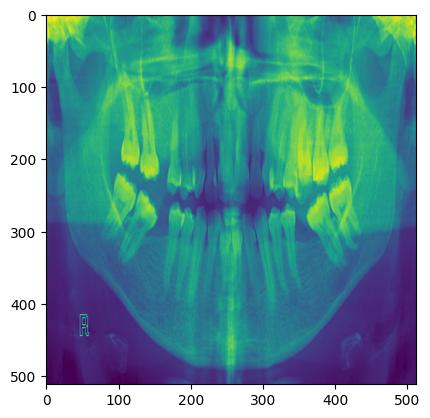

In [ ]:
#Checking data X  and Y matching
plt.imshow(x_train[random_number,:,:,0])

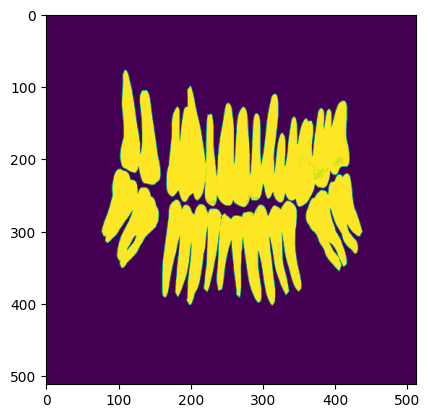

In [ ]:
#Checking data X  and Y matching
plt.imshow(y_train[random_number,:,:,0])

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, BatchNormalization, concatenate, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model

def conv_block(inputs, num_filters, l2_lambda):
    x = Conv2D(num_filters, (3, 3), activation='relu', padding='same',
               kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(inputs)
    x = Conv2D(num_filters, (3, 3), activation='relu', padding='same',
               kernel_initializer='he_normal', kernel_regularizer=l2(l2_lambda))(x)
    x = BatchNormalization()(x)
    return x

def UNetPlusPlus(input_shape=(512, 512, 1), last_activation='sigmoid', l2_lambda=0.01):
    inputs = Input(shape=input_shape)

    # Encoder path
    conv1_1 = conv_block(inputs, 32, l2_lambda)
    pool1_1 = MaxPooling2D(pool_size=(2, 2))(conv1_1)

    conv2_1 = conv_block(pool1_1, 64, l2_lambda)
    pool2_1 = MaxPooling2D(pool_size=(2, 2))(conv2_1)

    conv3_1 = conv_block(pool2_1, 128, l2_lambda)
    pool3_1 = MaxPooling2D(pool_size=(2, 2))(conv3_1)

    conv4_1 = conv_block(pool3_1, 256, l2_lambda)
    pool4_1 = MaxPooling2D(pool_size=(2, 2))(conv4_1)

    conv5_1 = conv_block(pool4_1, 512, l2_lambda)

    # Decoder path
    up4_2 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5_1)
    conv4_2 = conv_block(concatenate([up4_2, conv4_1]), 256, l2_lambda)

    up3_2 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv4_2)
    conv3_2 = conv_block(concatenate([up3_2, conv3_1]), 128, l2_lambda)

    up2_2 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv3_2)
    conv2_2 = conv_block(concatenate([up2_2, conv2_1]), 64, l2_lambda)

    up1_2 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv2_2)
    conv1_2 = conv_block(concatenate([up1_2, conv1_1]), 32, l2_lambda)

    # Nested connections
    up1_3 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv2_2)
    conv1_3 = conv_block(concatenate([conv1_2, up1_3]), 32, l2_lambda)

    up2_3 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv3_2)
    conv2_3 = conv_block(concatenate([conv2_2, up2_3, conv1_2]), 64, l2_lambda)

    up3_3 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv4_2)
    conv3_3 = conv_block(concatenate([conv3_2, up3_3, conv2_2, conv2_3]), 128, l2_lambda)

    conv4_3 = conv_block(concatenate([conv4_2, conv3_2, up4_2, conv3_3]), 256, l2_lambda)

    outputs = Conv2D(1, (1, 1), activation=last_activation, padding='same')(conv4_3)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Create the Nested U-Net (UNet++) model
model = UNetPlusPlus()

# Plot the model architecture
plot_model(model, to_file='unetplusplus_model.png', show_shapes=True, show_layer_names=True)


ValueError: A `Concatenate` layer requires inputs with matching shapes except for the concatenation axis. Received: input_shape=[(None, 256, 256, 64), (None, 256, 256, 64), (None, 512, 512, 32)]

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define the callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('/content/drive/MyDrive/archive (4)/model_weights.h5', monitor='val_loss', save_best_only=True, save_weights_only=True)
#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Now, you can use these callbacks in your model training
history = model.fit(x_train, y_train, batch_size=8, epochs=200, verbose=1,
                    validation_split=0.2, callbacks=[early_stopping, model_checkpoint])


Epoch 1/200
53/53 [==============================] - 129s 2s/step - loss: 26.4533 - accuracy: 0.3289 - val_loss: 6.0958 - val_accuracy: 0.4828
Epoch 2/200
53/53 [==============================] - 54s 1s/step - loss: 3.3436 - accuracy: 0.3584 - val_loss: 2.0548 - val_accuracy: 0.3429
Epoch 3/200
53/53 [==============================] - 56s 1s/step - loss: 1.4796 - accuracy: 0.3679 - val_loss: 1.3099 - val_accuracy: 0.3392
Epoch 4/200
53/53 [==============================] - 56s 1s/step - loss: 1.0390 - accuracy: 0.3677 - val_loss: 1.0812 - val_accuracy: 0.3392
Epoch 5/200
53/53 [==============================] - 56s 1s/step - loss: 1.0012 - accuracy: 0.3644 - val_loss: 1.0295 - val_accuracy: 0.3392
Epoch 6/200
53/53 [==============================] - 56s 1s/step - loss: 0.8007 - accuracy: 0.3662 - val_loss: 0.9032 - val_accuracy: 0.3392
Epoch 7/200
53/53 [==============================] - 55s 1s/step - loss: 0.8867 - accuracy: 0.3617 - val_loss: 0.9085 - val_accuracy: 0.3392
Epoch 8/200

In [ ]:
predict_img=model.predict(x_test)
predict=predict_img[1,:,:,0]

1/1 [==============================] - 15s 15s/step


In [ ]:
#Test
from sklearn.metrics import f1_score
import numpy as np
predict_img1=(predict_img>0.25)*1
y_test1=(y_test>0.25)*1

f1_score(predict_img1.flatten(), y_test1.flatten(), average='micro')

0.8916140469637784

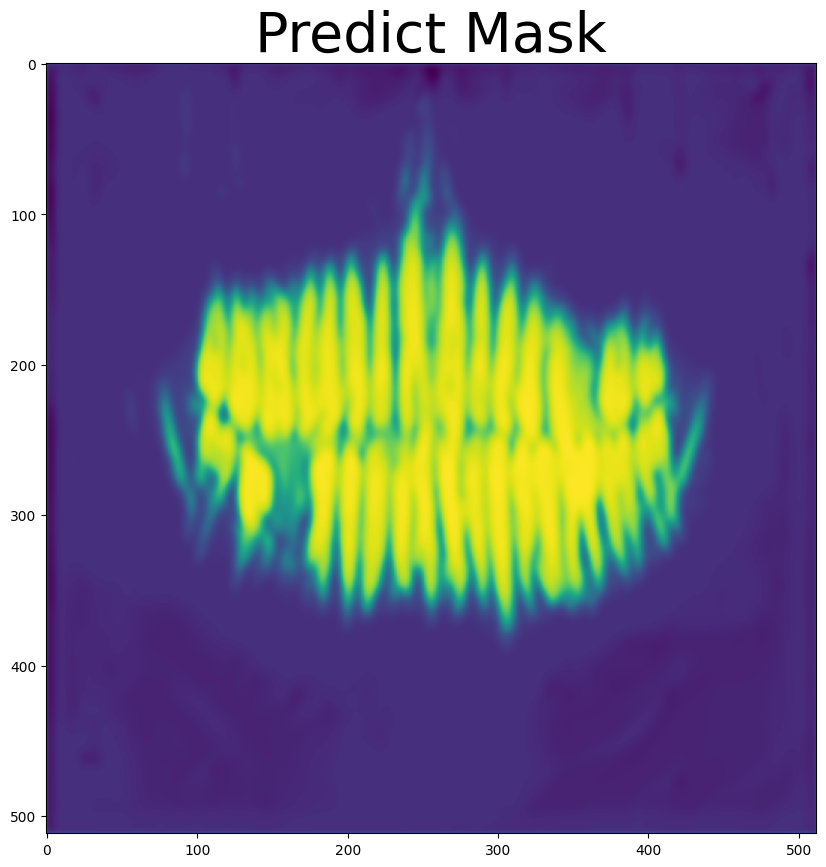

In [ ]:
plt.figure(figsize = (20,10))
plt.title("Predict Mask",fontsize = 40)
plt.imshow(predict)
plt.imsave("/content/drive/MyDrive/archive (4)/predict.png",predict)

In [ ]:
import cv2
import numpy as np
from imutils import perspective
from scipy.spatial import distance as dist
def midpoint(ptA, ptB):
	return ((ptA[0] + ptB[0]) * 0.5, (ptA[1] + ptB[1]) * 0.5)
# Load in image, convert to gray scale, and Otsu's threshold

#Function accept cv2 type
#Only useable splitted masks

def CCA_Analysis(orig_image,predict_image,erode_iteration,open_iteration):
    kernel1 =( np.ones((5,5), dtype=np.float32))
    kernel_sharpening = np.array([[-1,-1,-1],
                                  [-1,9,-1],
                                 [-1,-1,-1]])
    image = predict_image
    image2 =orig_image
    image=cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel1,iterations=open_iteration )
    image = cv2.filter2D(image, -1, kernel_sharpening)
    image=cv2.erode(image,kernel1,iterations =erode_iteration)
    image=cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    labels=cv2.connectedComponents(thresh,connectivity=8)[1]
    a=np.unique(labels)
    count2=0
    for label in a:
        if label == 0:
            continue

        # Create a mask
        mask = np.zeros(thresh.shape, dtype="uint8")
        mask[labels == label] = 255
        # Find contours and determine contour area
        cnts,hieararch = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cnts = cnts[0]
        c_area = cv2.contourArea(cnts)
        # threshhold for tooth count
        if c_area>2000:
            count2+=1

        (x,y),radius = cv2.minEnclosingCircle(cnts)
        rect = cv2.minAreaRect(cnts)
        box = cv2.boxPoints(rect)
        box = np.array(box, dtype="int")
        box = perspective.order_points(box)
        color1 = (list(np.random.choice(range(150), size=3)))
        color =[int(color1[0]), int(color1[1]), int(color1[2])]
        cv2.drawContours(image2,[box.astype("int")],0,color,2)
        (tl,tr,br,bl)=box

        (tltrX,tltrY)=midpoint(tl,tr)
        (blbrX,blbrY)=midpoint(bl,br)
    	# compute the midpoint between the top-left and top-right points,
    	# followed by the midpoint between the top-righ and bottom-right
        (tlblX,tlblY)=midpoint(tl,bl)
        (trbrX,trbrY)=midpoint(tr,br)
    	# draw the midpoints on the image
        cv2.circle(image2, (int(tltrX), int(tltrY)), 5, (255, 0, 0), -1)
        cv2.circle(image2, (int(blbrX), int(blbrY)), 5, (255, 0, 0), -1)
        cv2.circle(image2, (int(tlblX), int(tlblY)), 5, (255, 0, 0), -1)
        cv2.circle(image2, (int(trbrX), int(trbrY)), 5, (255, 0, 0), -1)
        cv2.line(image2, (int(tltrX), int(tltrY)), (int(blbrX), int(blbrY)),color, 2)
        cv2.line(image2, (int(tlblX), int(tlblY)), (int(trbrX), int(trbrY)),color, 2)
        dA = dist.euclidean((tltrX, tltrY), (blbrX, blbrY))
        dB = dist.euclidean((tlblX, tlblY), (trbrX, trbrY))



        pixelsPerMetric=1
        dimA = dA * pixelsPerMetric
        dimB = dB *pixelsPerMetric
        cv2.putText(image2, "{:.1f}pixel".format(dimA),(int(tltrX - 15), int(tltrY - 10)), cv2.FONT_HERSHEY_SIMPLEX,0.65, color, 2)
        cv2.putText(image2, "{:.1f}pixel".format(dimB),(int(trbrX + 10), int(trbrY)), cv2.FONT_HERSHEY_SIMPLEX,0.65, color, 2)
        cv2.putText(image2, "{:.1f}".format(label),(int(tltrX - 35), int(tltrY - 5)), cv2.FONT_HERSHEY_SIMPLEX,0.65, color, 2)
    teeth_count=count2
    return image2,teeth_count

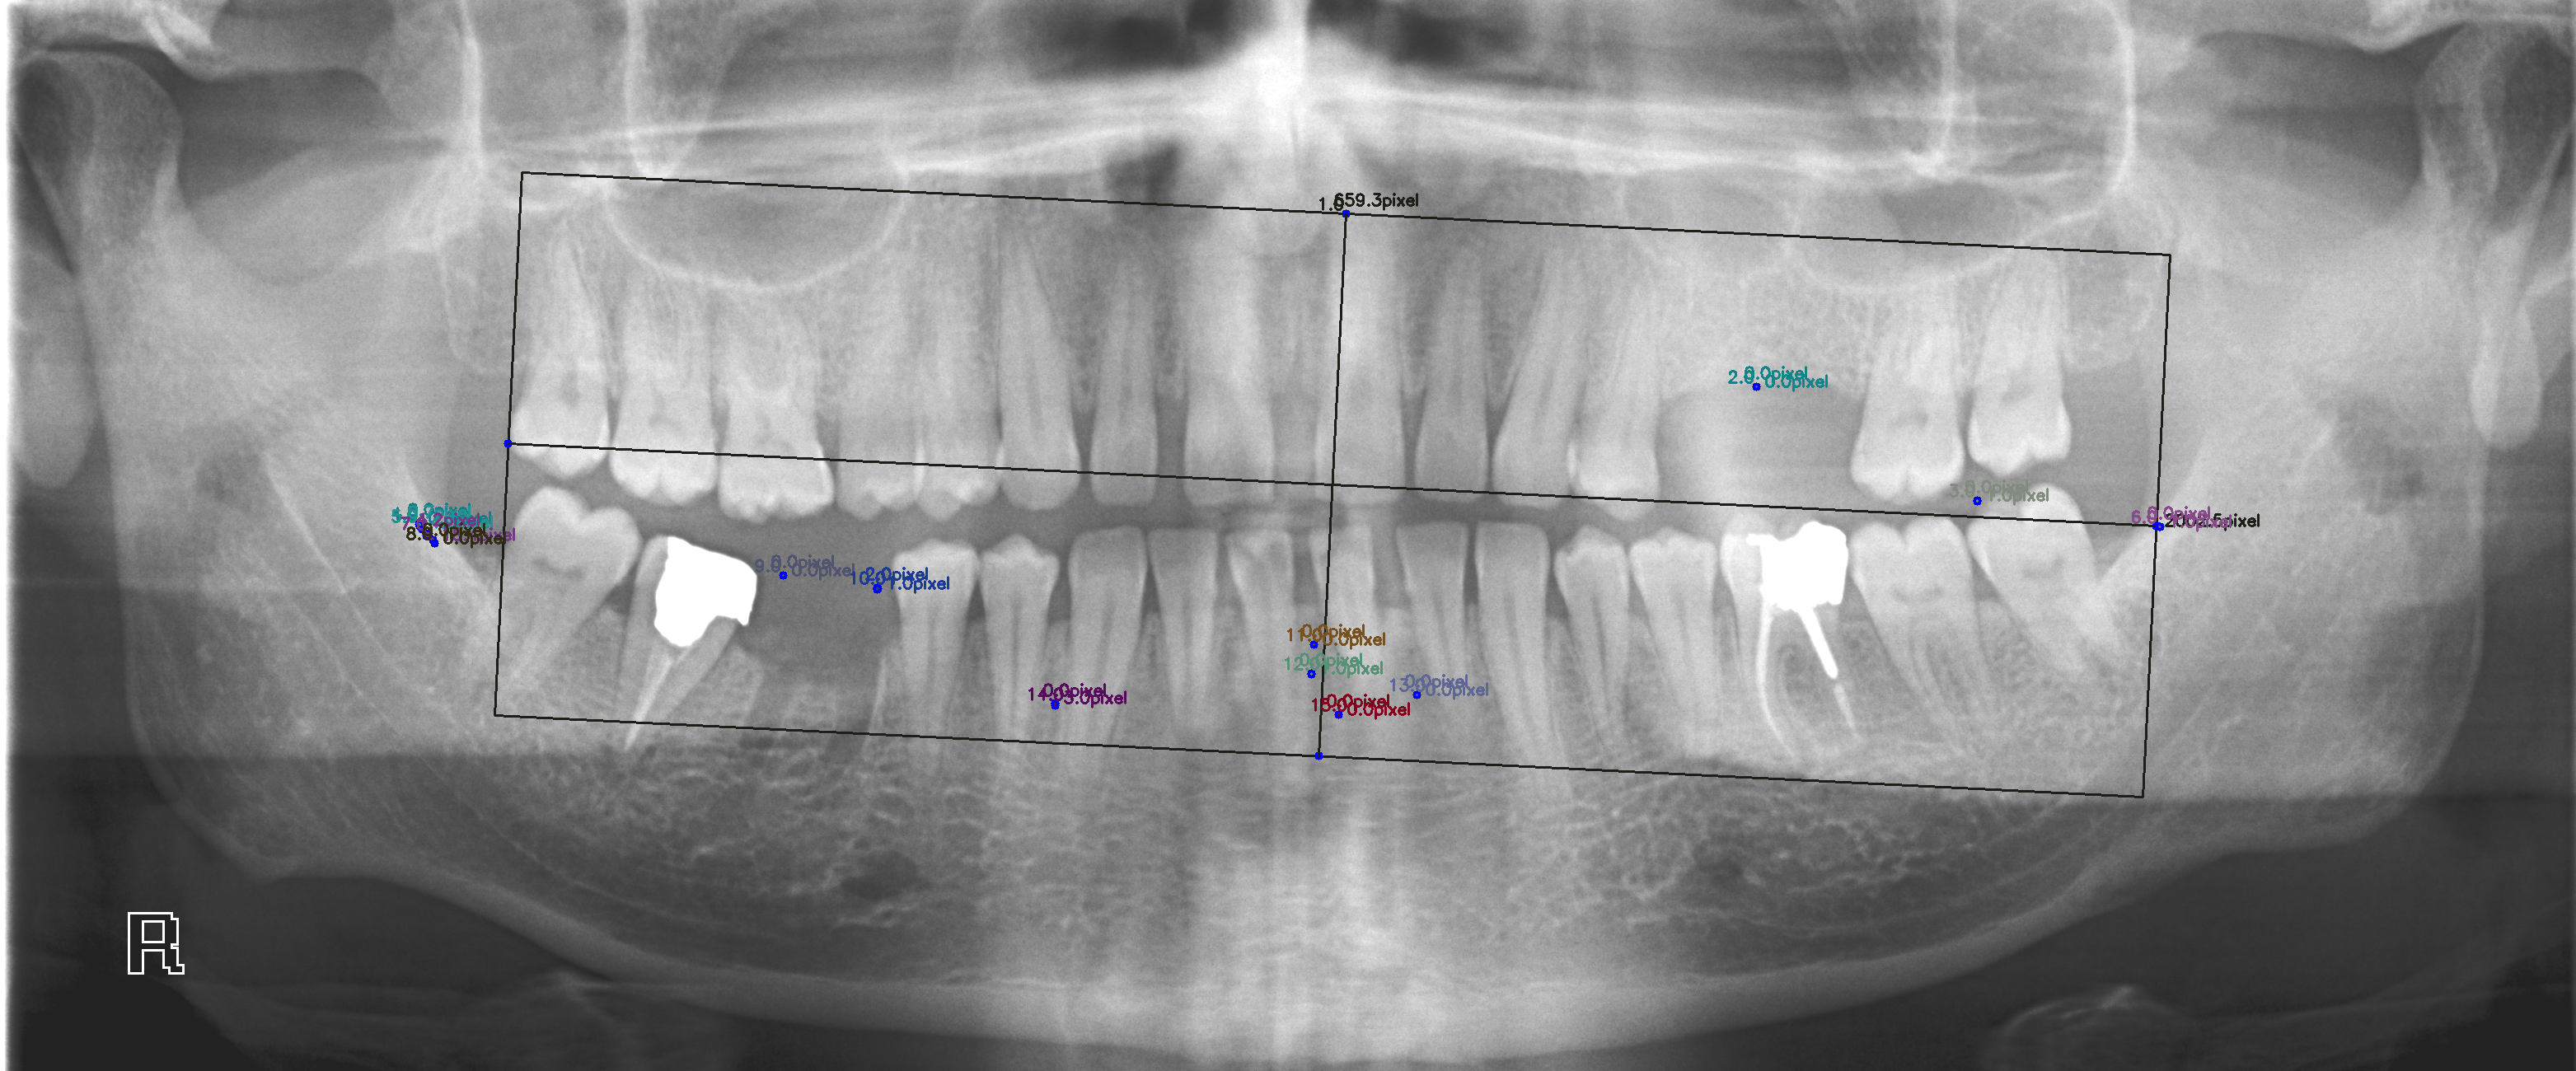

In [ ]:
from google.colab.patches import cv2_imshow
import cv2



##Plotting - RESULT Example with CCA_Analysis
img=cv2.imread("/content/drive/MyDrive/archive (4)/Images/107.png")#original img 107.png

#load image (mask was saved by matplotlib.pyplot)
predicted=cv2.imread("/content/drive/MyDrive/archive (4)/predict.png")

predicted = cv2.resize(predicted, (img.shape[1],img.shape[0]), interpolation=cv2.INTER_LANCZOS4)

cca_result,teeth_count=CCA_Analysis(img,predicted,3,2)
cv2_imshow(cca_result)

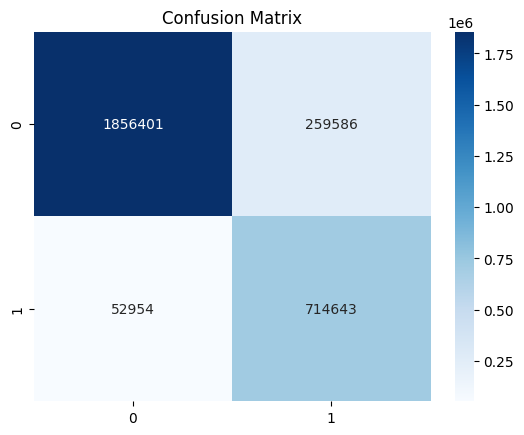

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve
#  data
predict_img1_flat = predict_img1.flatten()
y_test1_flat = y_test1.flatten()

# Confusion matrix
conf_matrix = sns.heatmap(confusion_matrix(y_test1_flat, predict_img1_flat), annot=True, fmt="d", cmap="Blues")
conf_matrix.set_title('Confusion Matrix')
plt.show()

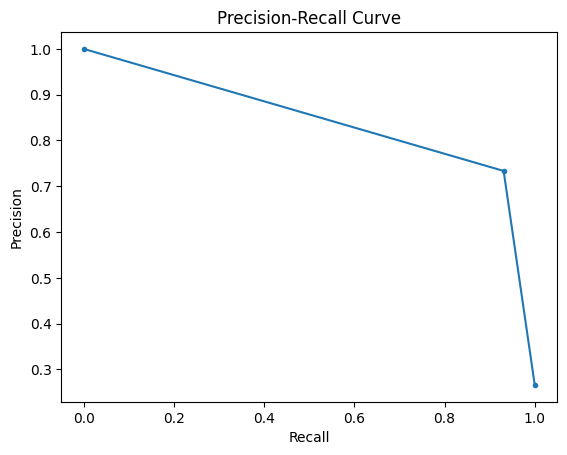

In [ ]:
# Precision-recall curve
precision, recall, _ = precision_recall_curve(y_test1_flat, predict_img1_flat)
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

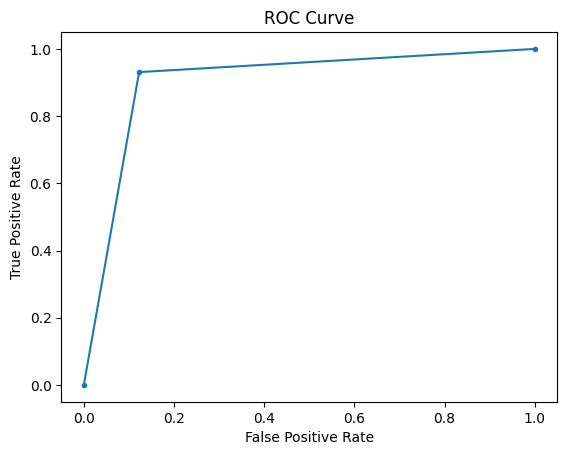

In [ ]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test1_flat, predict_img1_flat)
plt.plot(fpr, tpr, marker='.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [ ]:
print(teeth_count,"Teeth Count")

1 Teeth Count


In [ ]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 22.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 30.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 65.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.0/83.0 kB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 9.8 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import cv2
from keras.models import load_model
from skimage import measure, morphology

# Load the trained model
@st.cache(allow_output_mutation=True)
def load_trained_model(model_path):
    return load_model(model_path)

# Perform post-processing steps
def post_process(segmented_image):
    # Apply Opening Morphological Transformation
    kernel = np.ones((5, 5), np.uint8)
    opening = cv2.morphologyEx(segmented_image, cv2.MORPH_OPEN, kernel)

    # Apply Sharpening Filter
    sharpening_kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
    sharpened = cv2.filter2D(opening, -1, sharpening_kernel)

    # Apply Erosion Morphological Transformation
    erosion = cv2.erode(sharpened, kernel, iterations=1)

    # Apply Otsu Binarization
    _, otsu = cv2.threshold(erosion, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    return otsu

# Label the connected components
def label_components(binary_image):
    labels = measure.label(binary_image, connectivity=2)
    return labels

# Streamlit app
def main():
    st.title("Teeth Segmentation Model")

    model_path = st.text_input("Enter the path to the model file:", "/content/drive/MyDrive/archive (4)/model_weights.h5")
    if st.button("Load Model"):
        model = load_trained_model(model_path)
        st.success("Model Loaded Successfully")

    uploaded_file = st.file_uploader("Choose an image...", type="png")
    if uploaded_file is not None:
        input_image = cv2.imdecode(np.frombuffer(uploaded_file.read(), np.uint8), 1)
        st.image(input_image, caption='Uploaded Image', use_column_width=True)
        st.write("Classifying...")

        # Preprocess the image for the model
        input_image_resized = cv2.resize(input_image, (512, 512))
        input_image_normalized = input_image_resized / 255.0
        input_image_expanded = np.expand_dims(input_image_normalized, axis=0)

        # Get the model prediction
        prediction = model.predict(input_image_expanded)
        prediction_resized = cv2.resize(prediction[0], (512, 512))

        # Apply post-processing
        post_processed_image = post_process(prediction_resized)

        # Label connected components
        labeled_image = label_components(post_processed_image)

        # Display results
        st.image(prediction_resized, caption='Segmented Image', use_column_width=True)
        st.image(post_processed_image, caption='Post-Processed Image', use_column_width=True)
        st.image(labeled_image, caption='Labeled Components', use_column_width=True)

if __name__ == "__main__":
    main()


Writing app.py


In [ ]:
# Step 1: Install necessary packages
!pip install streamlit pyngrok


In [ ]:

# Step 2: Write the app.py file
%%writefile app.py
import streamlit as st
import numpy as np
import cv2
from keras.models import load_model
from skimage import measure, morphology

@st.cache(allow_output_mutation=True)
def load_trained_model(model_path):
    return load_model(model_path)

def post_process(segmented_image):
    kernel = np.ones((5, 5), np.uint8)
    opening = cv2.morphologyEx(segmented_image, cv2.MORPH_OPEN, kernel)
    sharpening_kernel = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
    sharpened = cv2.filter2D(opening, -1, sharpening_kernel)
    erosion = cv2.erode(sharpened, kernel, iterations=1)
    _, otsu = cv2.threshold(erosion, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return otsu

def label_components(binary_image):
    labels = measure.label(binary_image, connectivity=2)
    return labels

def main():
    st.title("Teeth Segmentation Model")
    model_path = st.text_input("Enter the path to the model file:", "/content/drive/MyDrive/archive (4)/model_weights.h5")
    if st.button("Load Model"):
        model = load_trained_model(model_path)
        st.success("Model Loaded Successfully")
    uploaded_file = st.file_uploader("Choose an image...", type="png")
    if uploaded_file is not None:
        input_image = cv2.imdecode(np.frombuffer(uploaded_file.read(), np.uint8), 1)
        st.image(input_image, caption='Uploaded Image', use_column_width=True)
        st.write("Classifying...")
        input_image_resized = cv2.resize(input_image, (512, 512))
        input_image_normalized = input_image_resized / 255.0
        input_image_expanded = np.expand_dims(input_image_normalized, axis=0)
        prediction = model.predict(input_image_expanded)
        prediction_resized = cv2.resize(prediction[0], (512, 512))
        post_processed_image = post_process(prediction_resized)
        labeled_image = label_components(post_processed_image)
        st.image(prediction_resized, caption='Segmented Image', use_column_width=True)
        st.image(post_processed_image, caption='Post-Processed Image', use_column_width=True)
        st.image(labeled_image, caption='Labeled Components', use_column_width=True)

if __name__ == "__main__":
    main()

# Step 3: Start Streamlit with ngrok
from pyngrok import ngrok
import subprocess

# Start the Streamlit app in the background
command = "streamlit run app.py"
process = subprocess.Popen(command.split())

# Expose the app to the internet
public_url = ngrok.connect(port='8501')
print(f"Streamlit app is live at: {public_url}")


Overwriting app.py


In [ ]:
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.41.192.230:8501



In [ ]:
streamlit run /usr/local/lib/python3.10/dist-packages/colab_kernel_launcher.py

SyntaxError: invalid syntax (<ipython-input-31-03ca03d515b4>, line 1)